# RDF Analysis Walkthrough

## Thymol - P8 Example

This notebook demonstrates a reproducible analysis of a selected radial distribution function (RDF) output from an atomistic molecular dynamics study of thymol-derived compounds interacting with lipid membranes.

The example uses:

`analysis/rdf/RDF_THYM_2_P8.xvg`

The workflow demonstrates how to:

- read a GROMACS `.xvg` output file
- ignore metadata and extract numerical data
- visualize the radial distribution function
- identify the strongest positive RDF peak
- report the corresponding distance
- interpret the result cautiously in its molecular dynamics context

The notebook is a portfolio and reproducibility extension built around processed molecular dynamics data from the research project.

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt

print("Current working directory:")
print(Path.cwd())

Current working directory:
d:\molecular-dynamics-analysis\notebooks


In [3]:
from pathlib import Path

rdf_file = Path("../analysis/rdf/RDF_THYM_2_P8.xvg")

print("File exists:", rdf_file.exists())
print("File path:", rdf_file.resolve())

File exists: True
File path: D:\molecular-dynamics-analysis\analysis\rdf\RDF_THYM_2_P8.xvg


In [4]:
distance = []
rdf = []

with rdf_file.open("r") as file:
    for line in file:
        line = line.strip()

        if not line:
            continue

        if line.startswith("#") or line.startswith("@"):
            continue

        values = line.split()

        distance.append(float(values[0]))
        rdf.append(float(values[1]))

print("Number of data points:", len(distance))
print("First 5 distances:", distance[:5])
print("First 5 RDF values:", rdf[:5])

Number of data points: 315
First 5 distances: [0.0, 0.002, 0.004, 0.006, 0.008]
First 5 RDF values: [0.0, 0.0, 0.0, 0.0, 0.0]


In [5]:
max_rdf = max(rdf)
peak_index = rdf.index(max_rdf)
peak_distance = distance[peak_index]

print(f"Maximum g(r): {max_rdf:.3f}")
print(f"Peak distance: {peak_distance:.3f} nm")

Maximum g(r): 21.712
Peak distance: 0.468 nm


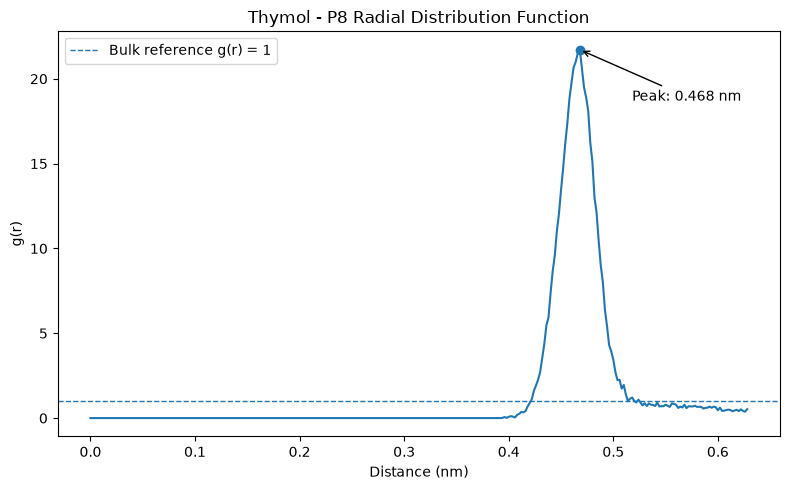

In [6]:
plt.figure(figsize=(8, 5))

plt.plot(distance, rdf, linewidth=1.5)

plt.axhline(
    y=1,
    linestyle="--",
    linewidth=1,
    label="Bulk reference g(r) = 1"
)

plt.scatter(
    peak_distance,
    max_rdf,
    zorder=3
)

plt.annotate(
    f"Peak: {peak_distance:.3f} nm",
    xy=(peak_distance, max_rdf),
    xytext=(peak_distance + 0.05, max_rdf - 3),
    arrowprops={"arrowstyle": "->"}
)

plt.xlabel("Distance (nm)")
plt.ylabel("g(r)")
plt.title("Thymol - P8 Radial Distribution Function")

plt.legend()
plt.tight_layout()

plt.show()

## Interpretation

The selected thymol-P8 radial distribution function shows a pronounced maximum at approximately **0.468 nm**, with a maximum `g(r)` value of approximately **21.7**.

This indicates strong enrichment of the selected P8 group at this separation relative to the bulk reference distribution.

The result should be interpreted as a preferred structural separation rather than direct proof of molecular binding. RDF information is most informative when considered together with the identities of the selected atoms and complementary analyses such as hydrogen bonding, density profiles, and ligand-membrane distance measurements.

This notebook reproduces the same peak-detection result obtained with the standalone `plot_rdf.py` workflow while showing each processing step explicitly.